# Appendicitis Prediction — DQN vs RAMAAS Baseline

**RL Framing:**
- **State**: binary feature vector ของอาการผู้ป่วย 1 ราย (9 features)
- **Action**: 0 = ไม่ผ่าตัด, 1 = ผ่าตัด
- **Reward**: สะท้อน medical cost ของการตัดสินใจผิด (Ratio 1:1)
- **เป้าหมาย**: Balance FN และ FP

**ข้อได้เปรียบของ DQN เหนือ Tabular RL:**
- ใช้ Neural Network แทน Q-Table → generalize ได้ดีกว่าบน unseen state
- รับ continuous/complex feature vector ได้โดยตรง
- มี Replay Buffer ช่วย break correlation ระหว่าง sample

## Cell 1 — Import Libraries

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import random
import shap
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.font_manager as fm
from collections import deque
from sklearn.metrics import confusion_matrix, roc_auc_score
from sklearn.model_selection import StratifiedKFold

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

# ---- Thai Font Setup ----
thai_candidates = ['Thonburi', 'TH Sarabun New', 'Noto Sans Thai', 'Tahoma', 'Arial Unicode MS']
thai_font = None
for font in thai_candidates:
    if fm.findfont(fm.FontProperties(family=font), fallback_to_default=False):
        thai_font = font
        break
if thai_font:
    plt.rcParams['font.family'] = thai_font
    print(f'Thai font: {thai_font}')
else:
    print('Thai font not found')

print(f"torch: {torch.__version__} | shap: {shap.__version__}")

Thai font: Thonburi
torch: 2.5.1 | shap: 0.48.0


## Cell 2 — Constants & Helper Functions

In [2]:
# ---- Features ----
BASE_FEATURES = ['Progression', 'Migration', 'Aggravation', 'TEMP', 'Rebound', 'WBC', 'Neut']
TARGET        = 'appendicitis'

# ---- Reward (1:1 ratio จาก sweep) ----
REWARD = {'TP': 15, 'TN': 10, 'FP': -100, 'FN': -100}

# ---- Hyperparameters ----
LR            = 0.0005
BATCH_SIZE    = 64
EPOCHS        = 2000
EPSILON_START = 1.0
EPSILON_MIN   = 0.01
EPSILON_DECAY = 0.995
TARGET_UPDATE = 100   # sync target net ทุกกี่ epoch
BUFFER_SIZE   = 10000
GAMMA         = 0.9
K_FOLDS       = 5


def to_bin(val):
    return 1 if str(val).lower().strip() in {'yes', '1', '1.0', '>10000', '>75', '>37.8', 'app'} else 0


def prepare_features(df):
    """แปลง raw features เป็น binary 7 ตัว (ตัด interaction features ออกจากผลทดสอบ: FN เท่ากัน)"""
    data = pd.DataFrame({col: df[col].map(to_bin).values for col in BASE_FEATURES})
    return data.values.astype(np.float32)


def prepare_features_amain(df):
    """สำหรับ result_compute_clean.csv — ข้อมูล 0/1 อยู่แล้ว ไม่ต้อง rename"""
    return prepare_features(df)


def calc_metrics(y_true, preds, scores):
    tn, fp, fn, tp = confusion_matrix(y_true, preds).ravel()
    total = len(y_true)
    acc   = (tp + tn) / total
    sens  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    spec  = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    prec  = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    f1    = 2 * prec * sens / (prec + sens) if (prec + sens) > 0 else 0.0
    auc   = roc_auc_score(y_true, scores) if len(np.unique(y_true)) > 1 else float('nan')
    return dict(TP=int(tp), TN=int(tn), FP=int(fp), FN=int(fn),
                Accuracy=acc, Sensitivity=sens, Specificity=spec, F1=f1, AUC=auc)


def evaluate_ramaas(df, y_true, threshold=0.5):
    """ประเมิน RAMAAS — สูตรดั้งเดิมจากหมอ"""
    BASE_WEIGHTS = {'Migration': 0.80, 'Progression': 1.04,
                    'Aggravation': 0.78, 'TEMP': 1.64,
                    'Rebound': 1.53, 'WBC': 0.91, 'Neut': 0.69}
    INTERCEPT = -3.37
    logit = INTERCEPT
    for feat, w in BASE_WEIGHTS.items():
        logit = logit + w * df[feat].values  # ข้อมูลเป็น 0/1 อยู่แล้ว
    probs = 1 / (1 + np.exp(-logit))
    preds = (probs >= threshold).astype(int)
    return calc_metrics(y_true, preds, probs)


FEATURE_NAMES = BASE_FEATURES  # 7 features (ไม่มี interaction features)
INPUT_SIZE    = len(FEATURE_NAMES)
print(f"✅ Setup เสร็จ | Input size: {INPUT_SIZE} features")
print(f"Features: {FEATURE_NAMES}")

✅ Setup เสร็จ | Input size: 7 features
Features: ['Progression', 'Migration', 'Aggravation', 'TEMP', 'Rebound', 'WBC', 'Neut']


## Cell 3 — DQN Architecture & Replay Buffer

In [3]:
class DQN_Network(nn.Module):
    def __init__(self, input_size, output_size=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, output_size)
        )
    def forward(self, x):
        return self.net(x)


class ReplayBuffer:
    def __init__(self, capacity=BUFFER_SIZE):
        self.buffer = deque(maxlen=capacity)
    def push(self, state, action, reward, next_state):
        self.buffer.append((state, action, reward, next_state))
    def sample(self, batch_size):
        return random.sample(self.buffer, batch_size)
    def __len__(self):
        return len(self.buffer)


def get_reward(action, truth):
    if   action == 1 and truth == 1: return REWARD['TP']
    elif action == 0 and truth == 0: return REWARD['TN']
    elif action == 1 and truth == 0: return REWARD['FP']
    else:                            return REWARD['FN']


def train_step(policy_net, target_net, optimizer, memory):
    """1 gradient update จาก replay buffer"""
    if len(memory) < BATCH_SIZE:
        return None
    batch = memory.sample(BATCH_SIZE)
    states, actions, rewards, next_states = zip(*batch)

    states      = torch.stack(states)
    next_states = torch.stack(next_states)
    actions     = torch.tensor(actions, dtype=torch.int64).unsqueeze(1)
    rewards     = torch.tensor(rewards, dtype=torch.float32)

    # Current Q
    current_q = policy_net(states).gather(1, actions).squeeze(1)

    # ✅ Bug fix: Target Q ใช้ target_net + GAMMA (ไม่ใช่แค่ rewards)
    with torch.no_grad():
        max_next_q = target_net(next_states).max(1)[0]
        target_q   = rewards + GAMMA * max_next_q

    loss = nn.MSELoss()(current_q, target_q)
    optimizer.zero_grad()
    loss.backward()
    nn.utils.clip_grad_norm_(policy_net.parameters(), 1.0)  # gradient clipping
    optimizer.step()
    return loss.item()


print("✅ DQN Architecture พร้อม")

✅ DQN Architecture พร้อม


## Cell 4 — Load Data

In [4]:
df_train = pd.read_csv('TRAIN_DATASET.csv')
df_test  = pd.read_csv('TEST_DATASET.csv')
train_states = prepare_features(df_train)
y_train      = df_train[TARGET].map(to_bin).values

# result_compute_clean.csv เป็น 0/1 อยู่แล้ว
test_states  = prepare_features_amain(df_test)
y_test       = df_test[TARGET].values

print(f"Train: {len(y_train)} samples (pos={y_train.sum()}, neg={(y_train==0).sum()})")
print(f"Test : {len(y_test)}  samples (pos={y_test.sum()},  neg={(y_test==0).sum()})")
print(f"Feature vector size: {train_states.shape[1]}")

Train: 500 samples (pos=348, neg=152)
Test : 376  samples (pos=266,  neg=110)
Feature vector size: 7


## Cell 5 — Training Function

In [5]:
def train_dqn(states, labels, verbose=True):
    """Train DQN บน states/labels ที่กำหนด คืน policy_net และ reward history"""
    policy_net = DQN_Network(INPUT_SIZE)
    target_net = DQN_Network(INPUT_SIZE)
    target_net.load_state_dict(policy_net.state_dict())
    target_net.eval()

    optimizer = optim.Adam(policy_net.parameters(), lr=LR)
    memory    = ReplayBuffer()
    epsilon   = EPSILON_START
    history   = []

    for epoch in range(EPOCHS):
        policy_net.train()
        epoch_reward = 0.0

        for i in range(len(states)):
            state      = torch.FloatTensor(states[i])
            truth      = int(labels[i])

            # Epsilon-greedy action
            if random.random() < epsilon:
                action = random.choice([0, 1])
            else:
                with torch.no_grad():
                    action = int(torch.argmax(policy_net(state)).item())

            reward       = get_reward(action, truth)
            epoch_reward += reward

            # ✅ next_state = state เดิม (bandit-style, terminal)
            memory.push(state, action, reward, state)
            train_step(policy_net, target_net, optimizer, memory)

        # Epsilon decay
        epsilon = max(EPSILON_MIN, epsilon * EPSILON_DECAY)

        # Sync target net
        if (epoch + 1) % TARGET_UPDATE == 0:
            target_net.load_state_dict(policy_net.state_dict())

        history.append(epoch_reward / len(states))

        if verbose and (epoch + 1) % 500 == 0:
            print(f"Epoch {epoch+1:4d}/{EPOCHS} | Eps: {epsilon:.3f} | Avg Reward: {history[-1]:.2f}")

    return policy_net, history


def evaluate_dqn(model, states, y_true):
    """ประเมิน DQN ด้วย greedy policy"""
    model.eval()
    X = torch.FloatTensor(states)
    with torch.no_grad():
        outputs = model(X)
        preds   = torch.argmax(outputs, dim=1).numpy()
        scores  = torch.softmax(outputs, dim=1)[:, 1].numpy()
    return calc_metrics(y_true, preds, scores)


print("✅ Training function พร้อม")

✅ Training function พร้อม


## Cell 6 — K-Fold Cross Validation (K=5)

In [6]:
# รวม train+test bootstrap สำหรับ CV
df_boot3   = pd.read_csv('TRAIN_DATASET.csv')

all_states = np.vstack([train_states,
                        prepare_features(df_boot3)])
y_all      = np.concatenate([y_train,
                             df_boot3[TARGET].map(to_bin).values])

skf        = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=42)
cv_results = []

print(f"🔄 เริ่ม {K_FOLDS}-Fold CV (DQN)...\n")
for fold, (tr_idx, val_idx) in enumerate(skf.split(all_states, y_all), 1):
    net, _ = train_dqn(all_states[tr_idx], y_all[tr_idx], verbose=False)
    m      = evaluate_dqn(net, all_states[val_idx], y_all[val_idx])
    cv_results.append(m)
    print(f"Fold {fold}: Sens={m['Sensitivity']:.2%}  Spec={m['Specificity']:.2%}  "
          f"F1={m['F1']:.4f}  FN={m['FN']}  FP={m['FP']}")

print("\n✅ CV เสร็จ")

🔄 เริ่ม 5-Fold CV (DQN)...

Fold 1: Sens=88.57%  Spec=65.00%  F1=0.8702  FN=16  FP=21
Fold 2: Sens=92.09%  Spec=54.10%  F1=0.8678  FN=11  FP=28
Fold 3: Sens=92.81%  Spec=50.82%  F1=0.8658  FN=10  FP=30
Fold 4: Sens=94.24%  Spec=50.82%  F1=0.8733  FN=8  FP=30
Fold 5: Sens=91.37%  Spec=55.74%  F1=0.8669  FN=12  FP=27

✅ CV เสร็จ


## Cell 7 — สรุปผล CV + Train Final & เปรียบเทียบ RAMAAS

In [7]:
# CV Summary
metric_keys = ['Accuracy', 'Sensitivity', 'Specificity', 'F1', 'AUC', 'FN', 'FP']
cv_row = {'Model': 'DQN (CV)'}
for k in metric_keys:
    vals = [f[k] for f in cv_results]
    m, s = np.mean(vals), np.std(vals)
    cv_row[k] = f"{m:.1f}±{s:.1f}" if k in ['FN','FP'] else (
                f"{m:.4f}±{s:.4f}" if k in ['F1','AUC'] else f"{m:.2%}±{s:.2%}")

print("\n" + "="*105)
print(f" {K_FOLDS}-Fold CV — DQN (Mean ± Std)")
print("="*105)
print(pd.DataFrame([cv_row]).to_string(index=False))
print("="*105)

# Train final model
print("\n🚀 Train Final DQN บน bootstrap2...")
policy_net, loss_history = train_dqn(train_states, y_train)

dqn_result    = evaluate_dqn(policy_net, test_states, y_test)
ramaas_result = evaluate_ramaas(df_test, y_test)

# Comparison table
rows = []
for name, m in [('RAMAAS (Baseline)', ramaas_result), ('DQN (RL)', dqn_result)]:
    rows.append({'Model': name,
                 'Accuracy': f"{m['Accuracy']:.2%}", 'Sensitivity': f"{m['Sensitivity']:.2%}",
                 'Specificity': f"{m['Specificity']:.2%}", 'F1': f"{m['F1']:.4f}",
                 'AUC': f"{m['AUC']:.4f}",
                 'TP': m['TP'], 'TN': m['TN'], 'FP': m['FP'], 'FN': m['FN']})

print("\n" + "="*95)
print(" RAMAAS vs DQN — Test Set (A-Main / ข้อมูลจริง)")
print("="*95)
print(pd.DataFrame(rows).to_string(index=False))
print("="*95)

print("\n📊 ความแตกต่าง (DQN − RAMAAS):")
for met in ['Accuracy', 'Sensitivity', 'Specificity', 'F1', 'AUC']:
    diff = dqn_result[met] - ramaas_result[met]
    print(f"  {met:<12}: {'↑' if diff > 0 else '↓'} {abs(diff):.4f}")
print(f"  FN change   : {dqn_result['FN'] - ramaas_result['FN']:+d} ราย")
print(f"  FP change   : {dqn_result['FP'] - ramaas_result['FP']:+d} ราย")


 5-Fold CV — DQN (Mean ± Std)
   Model     Accuracy  Sensitivity  Specificity            F1           AUC       FN       FP
DQN (CV) 80.70%±0.51% 91.82%±1.88% 55.30%±5.21% 0.8688±0.0027 0.7718±0.0132 11.4±2.7 27.2±3.3

🚀 Train Final DQN บน bootstrap2...
Epoch  500/2000 | Eps: 0.082 | Avg Reward: -8.86
Epoch 1000/2000 | Eps: 0.010 | Avg Reward: -5.68
Epoch 1500/2000 | Eps: 0.010 | Avg Reward: -6.99
Epoch 2000/2000 | Eps: 0.010 | Avg Reward: -7.02

 RAMAAS vs DQN — Test Set (A-Main / ข้อมูลจริง)
            Model Accuracy Sensitivity Specificity     F1    AUC  TP  TN  FP  FN
RAMAAS (Baseline)   70.21%      81.20%      43.64% 0.7941 0.6947 216  48  62  50
         DQN (RL)   78.46%      89.10%      52.73% 0.8541 0.7236 237  58  52  29

📊 ความแตกต่าง (DQN − RAMAAS):
  Accuracy    : ↑ 0.0824
  Sensitivity : ↑ 0.0789
  Specificity : ↑ 0.0909
  F1          : ↑ 0.0599
  AUC         : ↑ 0.0289
  FN change   : -21 ราย
  FP change   : -10 ราย


## Cell 8 — Visualization

/var/folders/kw/qqqmm03d3bj_8wzp121d4b000000gn/T/ipykernel_87538/985776348.py:72: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Thonburi.
  plt.savefig('dqn_final_results.png', dpi=150, bbox_inches='tight')
/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Thonburi.
  fig.canvas.print_figure(bytes_io, **kw)


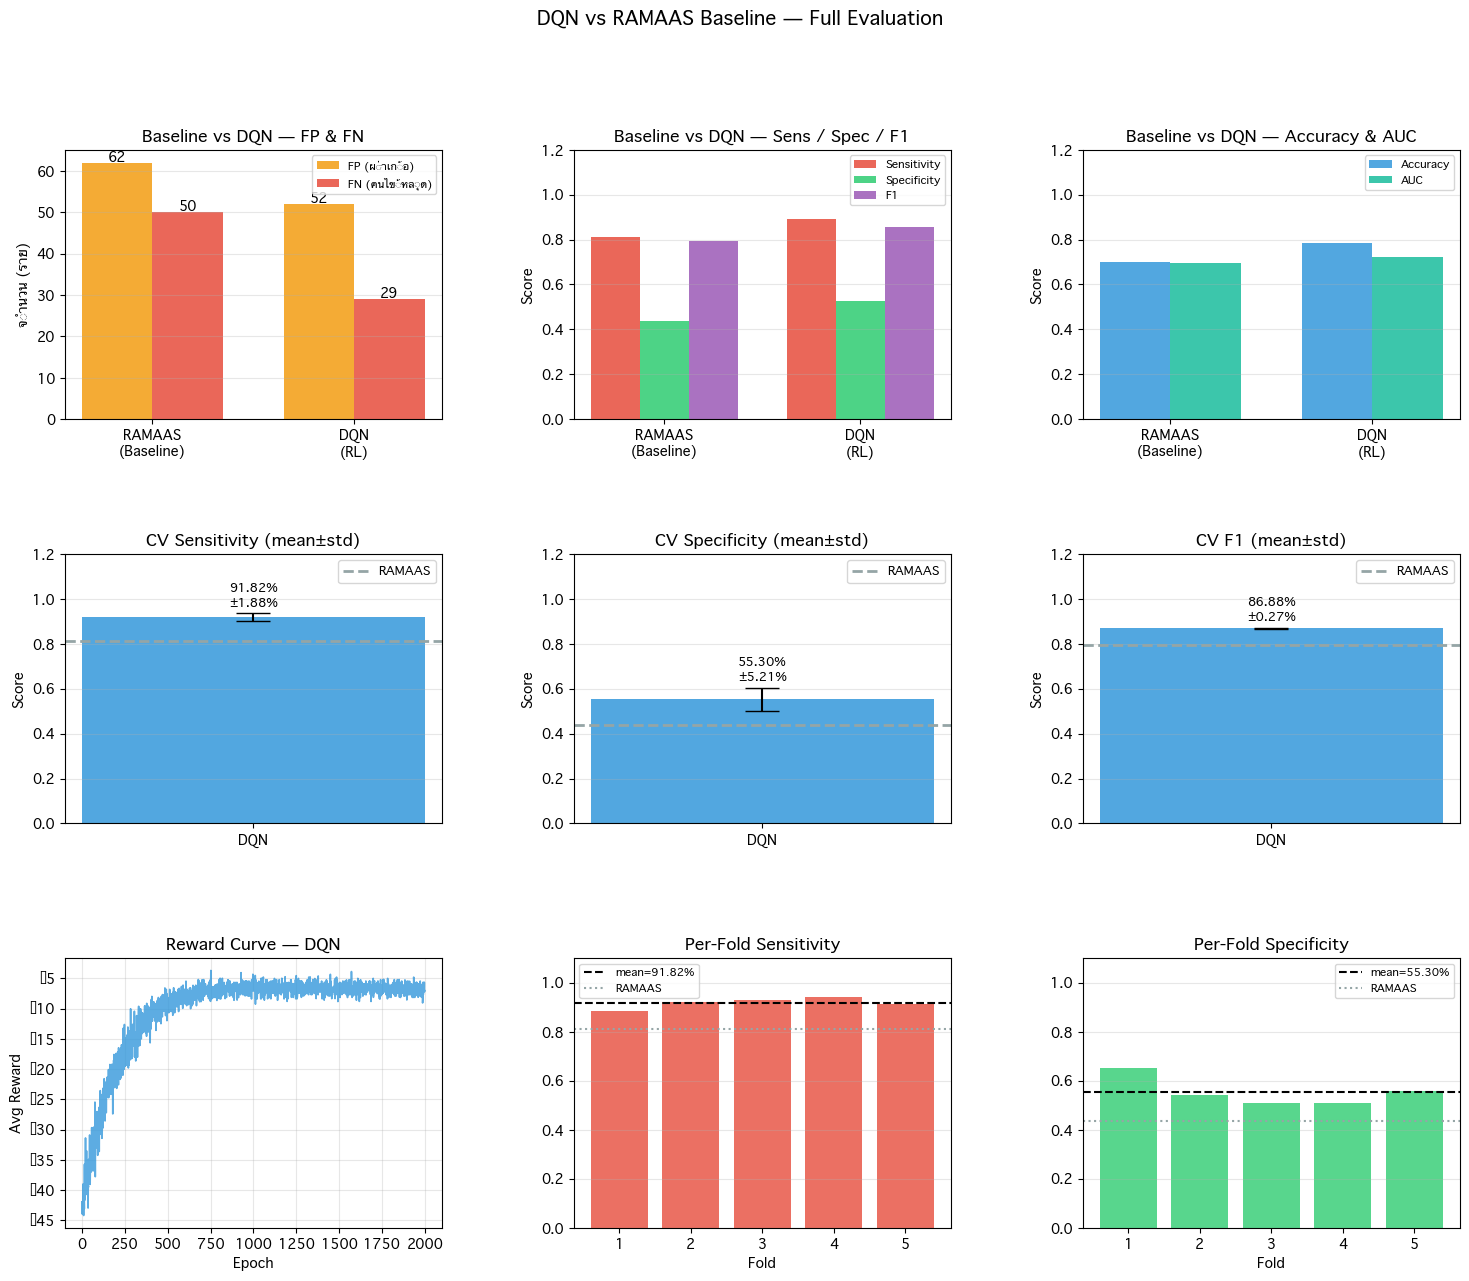

💾 บันทึกกราฟเป็น dqn_final_results.png


In [8]:
fig = plt.figure(figsize=(18, 14))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.5, wspace=0.35)
cmp_data   = [ramaas_result, dqn_result]
cmp_labels = ['RAMAAS\n(Baseline)', 'DQN\n(RL)']
x2, w = np.arange(2), 0.35

# Row 1: Baseline vs DQN
ax1 = fig.add_subplot(gs[0, 0])
ax1.bar(x2-w/2, [m['FP'] for m in cmp_data], w, label='FP (ผ่าเก้อ)',   color='#f39c12', alpha=0.85)
ax1.bar(x2+w/2, [m['FN'] for m in cmp_data], w, label='FN (คนไข้หลุด)', color='#e74c3c', alpha=0.85)
ax1.set_xticks(x2); ax1.set_xticklabels(cmp_labels)
ax1.set_title('Baseline vs DQN — FP & FN'); ax1.set_ylabel('จำนวน (ราย)')
ax1.legend(fontsize=8); ax1.grid(axis='y', alpha=0.3)
for i, m in enumerate(cmp_data):
    ax1.text(i-w/2, m['FP']+0.3, str(m['FP']), ha='center', fontsize=10, fontweight='bold')
    ax1.text(i+w/2, m['FN']+0.3, str(m['FN']), ha='center', fontsize=10, fontweight='bold')

ax2 = fig.add_subplot(gs[0, 1])
for j, (met, col) in enumerate(zip(['Sensitivity','Specificity','F1'],
                                    ['#e74c3c','#2ecc71','#9b59b6'])):
    ax2.bar(x2+(j-1)*0.25, [m[met] for m in cmp_data], 0.25, label=met, color=col, alpha=0.85)
ax2.set_xticks(x2); ax2.set_xticklabels(cmp_labels)
ax2.set_ylim(0, 1.2); ax2.set_title('Baseline vs DQN — Sens / Spec / F1')
ax2.set_ylabel('Score'); ax2.legend(fontsize=8); ax2.grid(axis='y', alpha=0.3)

ax3 = fig.add_subplot(gs[0, 2])
ax3.bar(x2-w/2, [m['Accuracy'] for m in cmp_data], w, label='Accuracy', color='#3498db', alpha=0.85)
ax3.bar(x2+w/2, [m['AUC']      for m in cmp_data], w, label='AUC',      color='#1abc9c', alpha=0.85)
ax3.set_xticks(x2); ax3.set_xticklabels(cmp_labels)
ax3.set_ylim(0, 1.2); ax3.set_title('Baseline vs DQN — Accuracy & AUC')
ax3.set_ylabel('Score'); ax3.legend(fontsize=8); ax3.grid(axis='y', alpha=0.3)

# Row 2: CV Mean ± Std
for col_idx, (met, title) in enumerate(zip(
        ['Sensitivity','Specificity','F1'],
        ['CV Sensitivity (mean±std)','CV Specificity (mean±std)','CV F1 (mean±std)'])):
    ax = fig.add_subplot(gs[1, col_idx])
    mv = np.mean([f[met] for f in cv_results])
    sv = np.std ([f[met] for f in cv_results])
    ax.bar([0], [mv], color='#3498db', alpha=0.85, yerr=[sv], capsize=12, width=0.4)
    ax.axhline(ramaas_result[met], color='#95a5a6', linestyle='--', linewidth=2, label='RAMAAS')
    ax.set_xticks([0]); ax.set_xticklabels(['DQN'])
    ax.set_ylim(0, 1.2); ax.set_title(title); ax.set_ylabel('Score')
    ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)
    ax.text(0, mv+sv+0.03, f"{mv:.2%}\n±{sv:.2%}", ha='center', fontsize=9, fontweight='bold')

# Row 3: Reward Curve + Per-fold
ax_r = fig.add_subplot(gs[2, 0])
ax_r.plot(loss_history, color='#3498db', linewidth=1.2, alpha=0.8)
ax_r.set_title('Reward Curve — DQN')
ax_r.set_xlabel('Epoch'); ax_r.set_ylabel('Avg Reward'); ax_r.grid(alpha=0.3)

ax_f1 = fig.add_subplot(gs[2, 1])
fold_sens = [f['Sensitivity'] for f in cv_results]
ax_f1.bar(range(1, K_FOLDS+1), fold_sens, color='#e74c3c', alpha=0.8)
ax_f1.axhline(np.mean(fold_sens), color='black', linestyle='--', linewidth=1.5,
              label=f"mean={np.mean(fold_sens):.2%}")
ax_f1.axhline(ramaas_result['Sensitivity'], color='#95a5a6', linestyle=':', linewidth=1.5, label='RAMAAS')
ax_f1.set_title('Per-Fold Sensitivity'); ax_f1.set_xlabel('Fold')
ax_f1.set_ylim(0, 1.1); ax_f1.legend(fontsize=8); ax_f1.grid(axis='y', alpha=0.3)

ax_f2 = fig.add_subplot(gs[2, 2])
fold_spec = [f['Specificity'] for f in cv_results]
ax_f2.bar(range(1, K_FOLDS+1), fold_spec, color='#2ecc71', alpha=0.8)
ax_f2.axhline(np.mean(fold_spec), color='black', linestyle='--', linewidth=1.5,
              label=f"mean={np.mean(fold_spec):.2%}")
ax_f2.axhline(ramaas_result['Specificity'], color='#95a5a6', linestyle=':', linewidth=1.5, label='RAMAAS')
ax_f2.set_title('Per-Fold Specificity'); ax_f2.set_xlabel('Fold')
ax_f2.set_ylim(0, 1.1); ax_f2.legend(fontsize=8); ax_f2.grid(axis='y', alpha=0.3)

plt.suptitle('DQN vs RAMAAS Baseline — Full Evaluation', fontsize=14, fontweight='bold')
plt.savefig('dqn_final_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("💾 บันทึกกราฟเป็น dqn_final_results.png")

## Cell 9 — Permutation Feature Importance

=== PERMUTATION FEATURE IMPORTANCE ===
WBC                  | FN +29  | Sens Drop 0.1090 | Acc Drop 0.1090
Rebound              | FN +15  | Sens Drop 0.0564 | Acc Drop 0.0984
Progression          | FN +12  | Sens Drop 0.0451 | Acc Drop 0.0559
Neut                 | FN +12  | Sens Drop 0.0451 | Acc Drop 0.0532
TEMP                 | FN +11  | Sens Drop 0.0414 | Acc Drop 0.0452
Migration            | FN +10  | Sens Drop 0.0376 | Acc Drop 0.0426
Aggravation          | FN +3   | Sens Drop 0.0113 | Acc Drop 0.0106


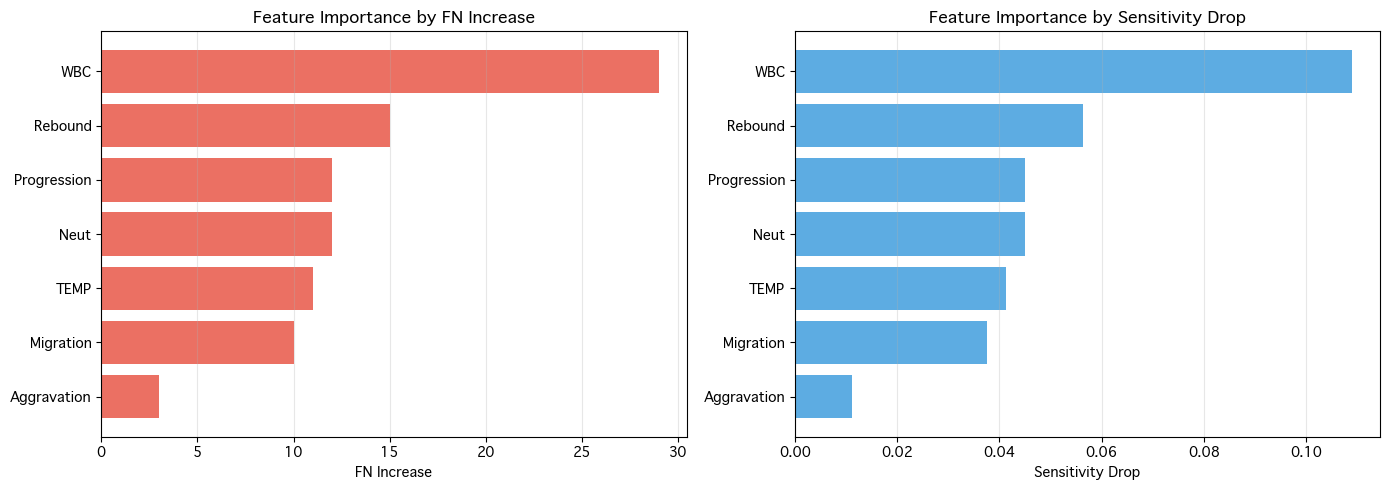

In [9]:
policy_net.eval()
X_test_t = torch.FloatTensor(test_states)
y_test_t = torch.tensor(y_test, dtype=torch.long)

def eval_torch(model, X, y):
    with torch.no_grad():
        preds = torch.argmax(model(X), dim=1)
    tp = int(((preds==1)&(y==1)).sum())
    tn = int(((preds==0)&(y==0)).sum())
    fp = int(((preds==1)&(y==0)).sum())
    fn = int(((preds==0)&(y==1)).sum())
    sens = tp/(tp+fn) if (tp+fn)>0 else 0
    acc  = (tp+tn)/len(y)
    return dict(sens=sens, acc=acc, fn=fn)

baseline = eval_torch(policy_net, X_test_t, y_test_t)
perm_results = []

for i, fname in enumerate(FEATURE_NAMES):
    X_perm = X_test_t.clone()
    X_perm[:, i] = X_perm[torch.randperm(X_perm.shape[0]), i]
    m = eval_torch(policy_net, X_perm, y_test_t)
    perm_results.append({
        'Feature'     : fname,
        'FN_Increase' : m['fn']   - baseline['fn'],
        'Sens_Drop'   : baseline['sens'] - m['sens'],
        'Acc_Drop'    : baseline['acc']  - m['acc'],
    })

perm_results = sorted(perm_results, key=lambda x: (x['FN_Increase'], x['Sens_Drop']), reverse=True)

print("=== PERMUTATION FEATURE IMPORTANCE ===")
for r in perm_results:
    print(f"{r['Feature']:<20} | FN +{r['FN_Increase']:<3} | Sens Drop {r['Sens_Drop']:.4f} | Acc Drop {r['Acc_Drop']:.4f}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
names = [r['Feature'] for r in perm_results]

axes[0].barh(names, [r['FN_Increase'] for r in perm_results], color='#e74c3c', alpha=0.8)
axes[0].invert_yaxis(); axes[0].set_xlabel('FN Increase')
axes[0].set_title('Feature Importance by FN Increase'); axes[0].grid(axis='x', alpha=0.3)

axes[1].barh(names, [r['Sens_Drop'] for r in perm_results], color='#3498db', alpha=0.8)
axes[1].invert_yaxis(); axes[1].set_xlabel('Sensitivity Drop')
axes[1].set_title('Feature Importance by Sensitivity Drop'); axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('dqn_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()